# <a id='toc1_'></a>[Analyse epi Daten, originär vs aus klin. generiert](#toc0_)

**Table of contents**<a id='toc0_'></a>    
- [Analyse epi Daten, originär vs aus klin. generiert](#toc1_)    
  - [Zusammenfassung](#toc1_1_)    
  - [intro code](#toc1_2_)    
  - [load data ⏳🔒](#toc1_3_)    
  - [Analyse](#toc1_4_)    
    - [epi Daten aus klin ("neu")](#toc1_4_1_)    
    - [epi Daten originär ("alt")](#toc1_4_2_)    
    - [Beispiel aus _neuen epi Daten_: Person mit max. Anzahl Tumormeldungen](#toc1_4_3_)    
  - [Datenstand 🕥](#toc1_5_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

## <a id='toc1_1_'></a>[Zusammenfassung](#toc0_)
- Hintergrund
  - Bei den epi Daten wird ein Algorithmus eingesetzt zur Erkennung von Mehrfachtumoren
  - Tumore, die nach dieser Erkennung als "nicht-mehrfach" markiert werden, bekommen eine aufsteigende Zählnummer (`TUMID`)
  - die TUMID gibt also an, wie viele Tumore einer Person jeweils zugeordnet sind, in welcher Reihenfolge
  - Tumore mit leerer TUMID werden als Mehrfachtumore ausgeschlossen
- Ziel
  - der Algorithmus soll auf die aus den klinischen Daten abgeleiteten epi Daten angewandt werden, insbesondere auf die Daten der Neuen Bundesländer (NBL)
  - zu prüfen: entstehen dabei Artefakte in den Daten?
- Daten (beides inklusive aller auszuschliessenden Fälle auf Basis von A Prüfungen)
  - originäre epi Daten (alt) 
  - aus klin Daten abgeleitete epi Daten (neu)
- **Fazit: ⚖️ die Identifikation von Mehrfachtumoren (=Zuordnung von leerer TUMID) führt in den neuen Daten zu vergleichbaren Effekten wie in den alten Daten und erscheint somit geeignet. Ein Ausschluss der sehr ähnlichen best-of Meldungen sollte dennoch vorab geprüft werden. Aktuell würden ~6.9k Fälle als Mehrfachtumore ausgeschlossen werden**

## <a id='toc1_3_'></a>[load data ⏳🔒](#toc0_)

In [1]:
import os
import pandas as pd
import datetime as dt
from importlib import metadata as md
from pandas_plots import tbl, pls, hlp
from connection_helper import sql
from pathlib import Path
import duckdb as ddb

hlp.show_package_version()
os.environ['THEME']='light'
dir_db=Path("../../cancerdata-workflow/out/db/")

📦 pandas: 2.2.2 | 📦 numpy: 1.26.4 | 📦 duckdb: 1.0.0 | 📦 pandas-plots: 0.11.2 | 📦 connection_helper: 0.7.2


In [2]:
con = ddb.connect()
con.execute("PRAGMA disable_progress_bar;")
con.execute(f"ATTACH DATABASE '{dir_db/'data_epi_internal.db'}' AS epi;")

dim_dig, dim_dsich_clin, dim_dsich_epi, dim_grading, dim_grading_clin, dim_grading_epi, dim_icd10, dim_icd10_3d, dim_lieferregister, dim_tnm_t, dim_tnm_uicc, dim_tree=sql.unpack_files_to_duckdb(
    dir=Path("data/dim"),
    con=con,
    ext="csv",
    prefix="dim_",
    # debug=True,
    # verbose=True,
)

In [3]:
ClinToEpi = con.sql("select * from epi.ClinToEpi")
Tumor4 = con.sql("select * from epi.Tumor4")

In [4]:
_histos = str((9990, 9697, 9617))
_df_n=(
    ClinToEpi
        .filter(f"HISC in {_histos}")
        .aggregate("EKRNR,HISC, count(*) as cnt")
        .join(dim_lieferregister,"code = EKRNR")
        .to_df()
        .pivot_table(index="HISC", columns="kkr", values="cnt", aggfunc="sum", fill_value=0)
)

tbl.show_num_df(_df_n, heatmap_axis="xy", total_exclude=True)


kkr,05-NW,09-BY,11-BE,12-BB,13-MV,14-SN,15-ST,16-TH,Total
HISC,,,,,,,,,
9617,0,2,0,1,1,2,1,1,8
9697,46,0,0,0,1,2,1,0,50
9990,0,0,955,1_245,33,5,4,57,2_299
Total,46,2,955,1_246,35,9,6,58,2_357


In [18]:
# todo rewrite in duckdb
df_epi_old=Tumor4.project("EKRNR, TUMID,CREATED").to_df().astype({"TUMID": "Int64"})
df_epi_new = ClinToEpi.project("GLOBALPATID, EKRNR, TUMID, DALTIMP, GKZlk, ICDGM10, ICDGM10DREI, ICDO3, DSICH, GRAD, DIG, HISC, LOKS, DCO, DJ, UICC, SEX, GDIMP, TOD, SDIMP, LOKGRP, HISCGRP, when_1_to_view").to_df().astype({"TUMID": "Int64"})

## <a id='toc1_4_'></a>[Analyse](#toc0_)
- Anteil an leeren TUMID (=Mehrfachtumor) in beiden Datenräumen konstant bei `0.3%` 👍 In der Verteilung nach KR gibt es keine Häufungen
- in neuen epi Daten: max 54 Fälle einem Patienten zugeordnet (alten Daten: 8) 👎 was an nicht aufgelösten best-of Meldungen liegen kann
- die Verteilung der TUMID ist ein beiden Datensätzen ähnlich (abgesehen von den seltenen Extremwerten in den neuen Daten) 👍
- neue Daten: in den NBL liegt die durchschn. TUMID leicht höher als im Westen, was tendenziell mehr zu der hohen Zahl an best-of Meldungen beiträgt

> `TUMID=0` kann offenbar im Algorithmus gesetzt werden (wenn Fall in Menge A3), und wird in der Union SQL Tabelle auf Ebene 4 geschrieben. Diese (wenigen) Fälle werden auf Ebene 5 dann zu `TUMID=1`, da die Reihenfolge der TUMID dann ausgezählt wird. RKI Doku [hier](https://dms-vbs.rki.local/fsc/mx/COO.2219.100.6.49845)  
> A3: Hilfsmenge: alle Meldungen, die eine ungültige Kombination von ICD10/DIG/HISC aufweisen (müsste nach der Neukodierung eigentlich ausgeschlossen sein). Diese Menge wird von der Grundmenge A1 abgezogen, es verbleiben nur gültige Meldungen 

In [6]:
def examine_tumid(df: pd.DataFrame) -> None:
    _df=df[["TUMID","EKRNR"]].copy()
    _df["TUMID_"] = _df["TUMID"].astype(str)

    print(f"Fallzahl: {(n:=len(_df)):_} | leere TUMID: {(tumid_0:=len(_df[_df['TUMID'].isna()])):_} | Quota = {tumid_0/n:.2%}")
    print(f"max. TUMID im Datensatz: {_df['TUMID'].astype('Int64').max()}")

    print("Verteilung #TUMID pro EKR (mean):")
    _df_mean=_df.groupby("EKRNR", dropna=False,as_index=False, observed=False)["TUMID"].mean().set_index("EKRNR")
    display(tbl.show_num_df(_df_mean.T.astype(float), total_axis="", heatmap_axis="x", precision=3, kpi_mode="min_max_xy"))
    
    print("Verteilung leere TUMID pro EKR (Anteil in %):")
    _df["TUMID_empty"] = _df["TUMID"].isna()
    _df_grp2 = _df.assign(Gesamt=1).groupby("EKRNR", dropna=False,as_index=False, observed=False).agg({"Gesamt": "sum", "TUMID_empty": "sum"})
    _df_grp2["pct"] = _df_grp2["TUMID_empty"] / _df_grp2["Gesamt"] * 100
    display(tbl.show_num_df(_df_grp2.set_index("EKRNR").T.astype(int), total_axis="", heatmap_axis="x"))
    
    pls.plot_bars(_df["TUMID_"].value_counts(dropna=False).reset_index(), orientation="v",top_n_index=20, sort_values=True)

    _df_grp=_df.assign(Anzahl=1).groupby(["EKRNR","TUMID_"],as_index=False, dropna=False, observed=False)["Anzahl"].sum()
    pls.plot_stacked_bars(_df_grp, orientation="h",top_n_color=10, sort_values=False, height=800, relative=True, show_total=True)
    
    return

### <a id='toc1_4_1_'></a>[epi Daten aus klin ("neu")](#toc0_)

Fallzahl: 2_307_232 | leere TUMID: 6_928 | Quota = 0.30%
max. TUMID im Datensatz: 54
Verteilung #TUMID pro EKR (mean):


EKRNR,01,02,03,04,05,06,07,08,09,10,11,12,13,14,15,16
TUMID,1.086 ⬜,1.070 ⬜,0.996 ⬜,1.089 ⬜,1.054 ⬜,1.032 ⬜,0.956 🟩,1.034 ⬜,1.226 ⬜,1.041 ⬜,1.010 ⬜,1.133 ⬜,1.430 ⬜,2.022 ⬜,1.520 ⬜,2.052 🟥


Verteilung leere TUMID pro EKR (Anteil in %):


EKRNR,01,02,03,04,05,06,07,08,09,10,11,12,13,14,15,16
Gesamt,106_085,53_582,148_351,19_202,541_490,112_553,87_374,244_671,318_061,32_814,81_867,76_839,78_599,249_258,93_698,62_788
TUMID_empty,140,139,87,5,2_162,55,68,2_208,705,39,194,383,135,323,188,97
pct,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


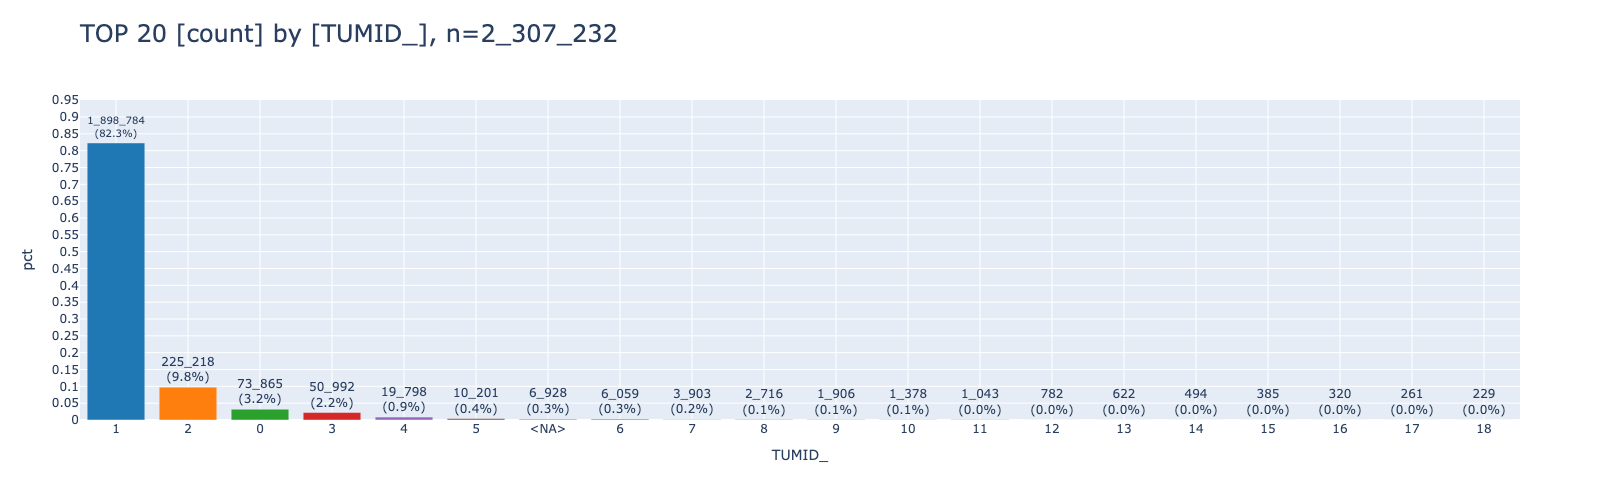

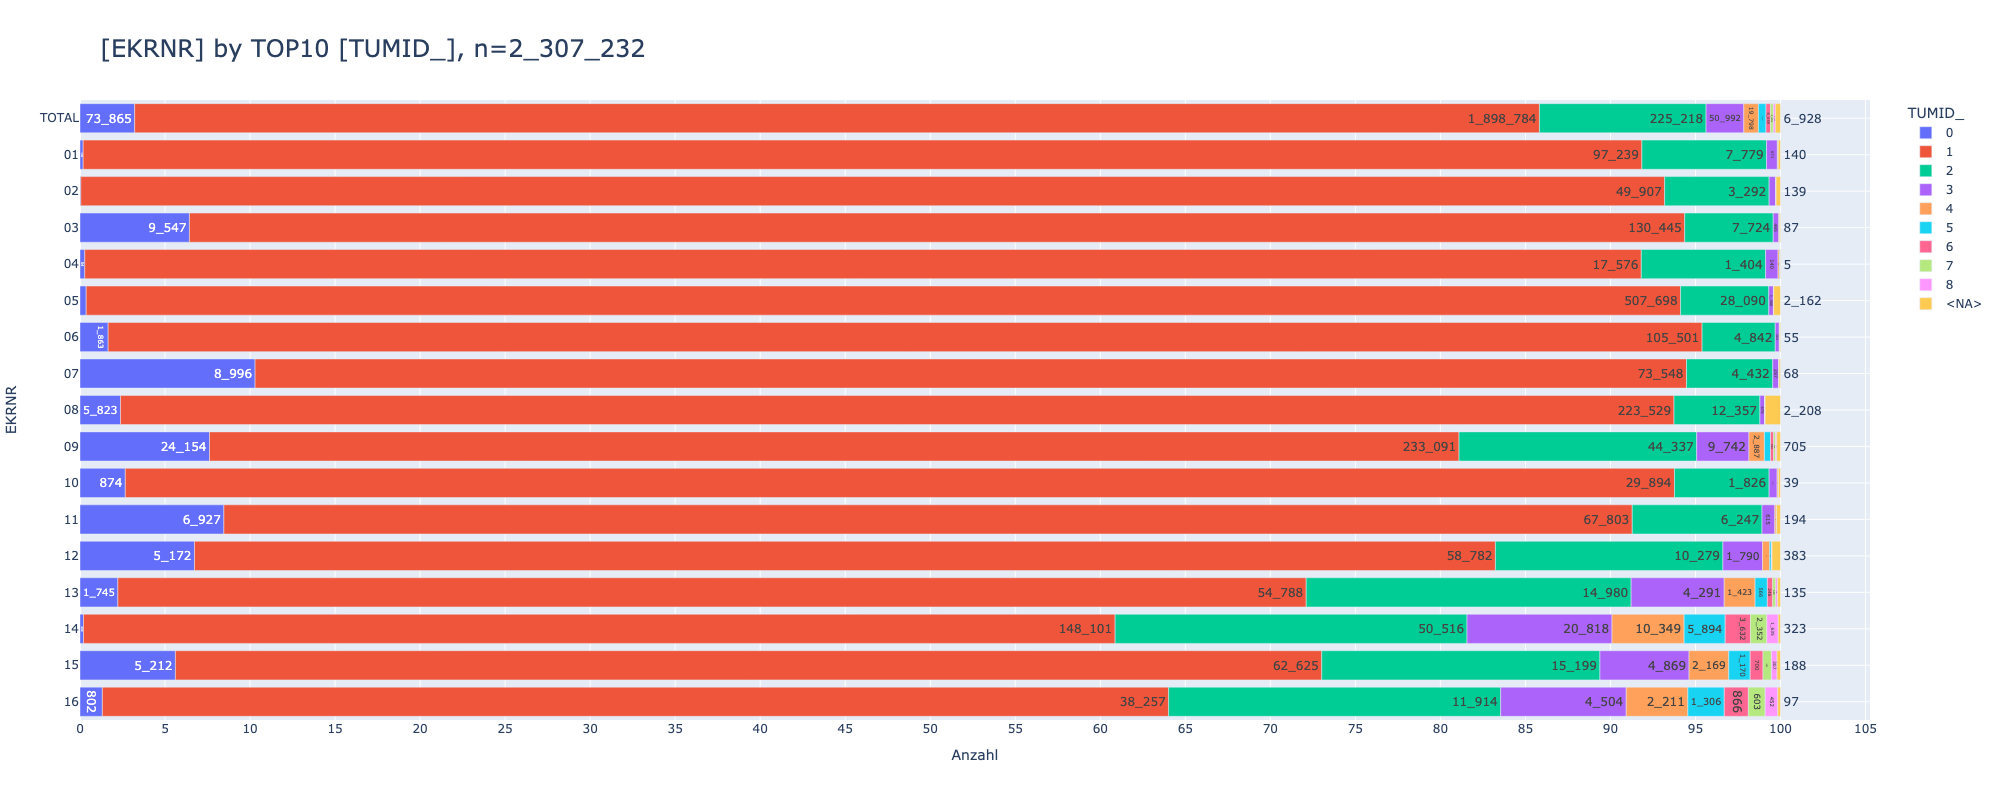

In [7]:
examine_tumid(df_epi_new)

### <a id='toc1_4_2_'></a>[epi Daten originär ("alt")](#toc0_)

Fallzahl: 12_009_425 | leere TUMID: 45_418 | Quota = 0.38%
max. TUMID im Datensatz: 10
Verteilung #TUMID pro EKR (mean):


EKRNR,01,02,03,04,05,06,07,08,09,10
TUMID,1.205 🟥,1.183 ⬜,1.195 ⬜,1.199 ⬜,1.154 ⬜,1.116 🟩,1.161 ⬜,1.126 ⬜,1.128 ⬜,1.156 ⬜


Verteilung leere TUMID pro EKR (Anteil in %):


EKRNR,01,02,03,04,05,06,07,08,09,10
Gesamt,734_305,423_109,1_816_413,151_753,3_881_747,918_534,823_343,1_048_203,1_811_372,400_646
TUMID_empty,1_333,3_155,16_164,336,9_038,1_510,2_490,1_169,2_139,8_084
pct,0,0,0,0,0,0,0,0,0,2


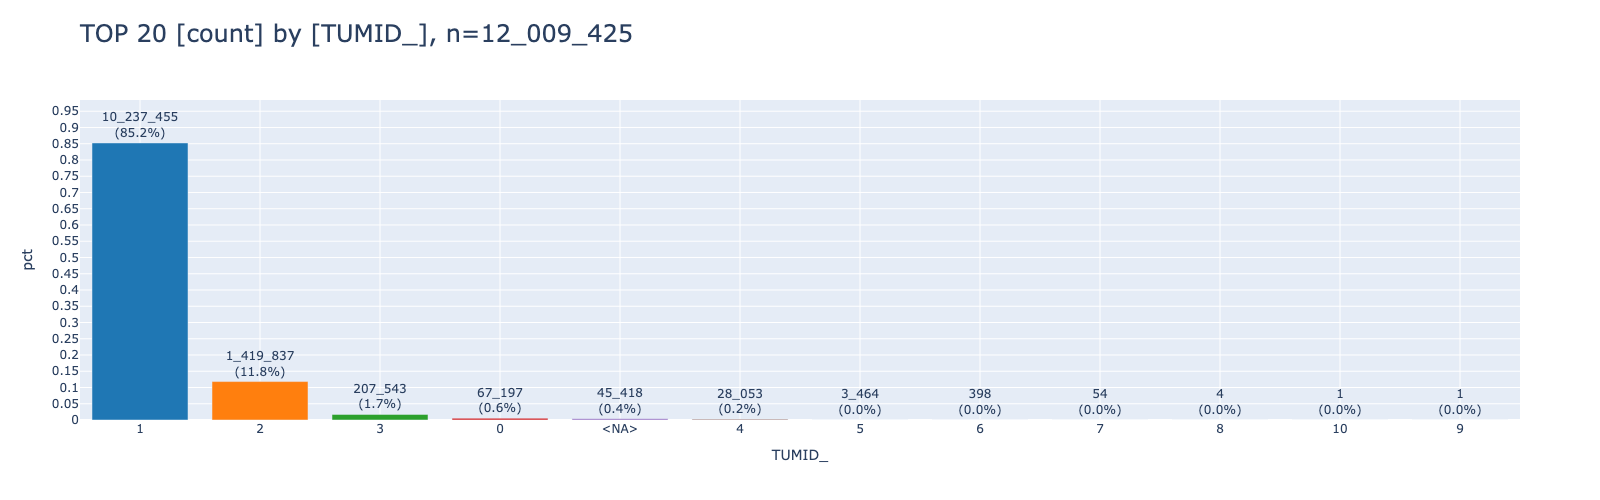

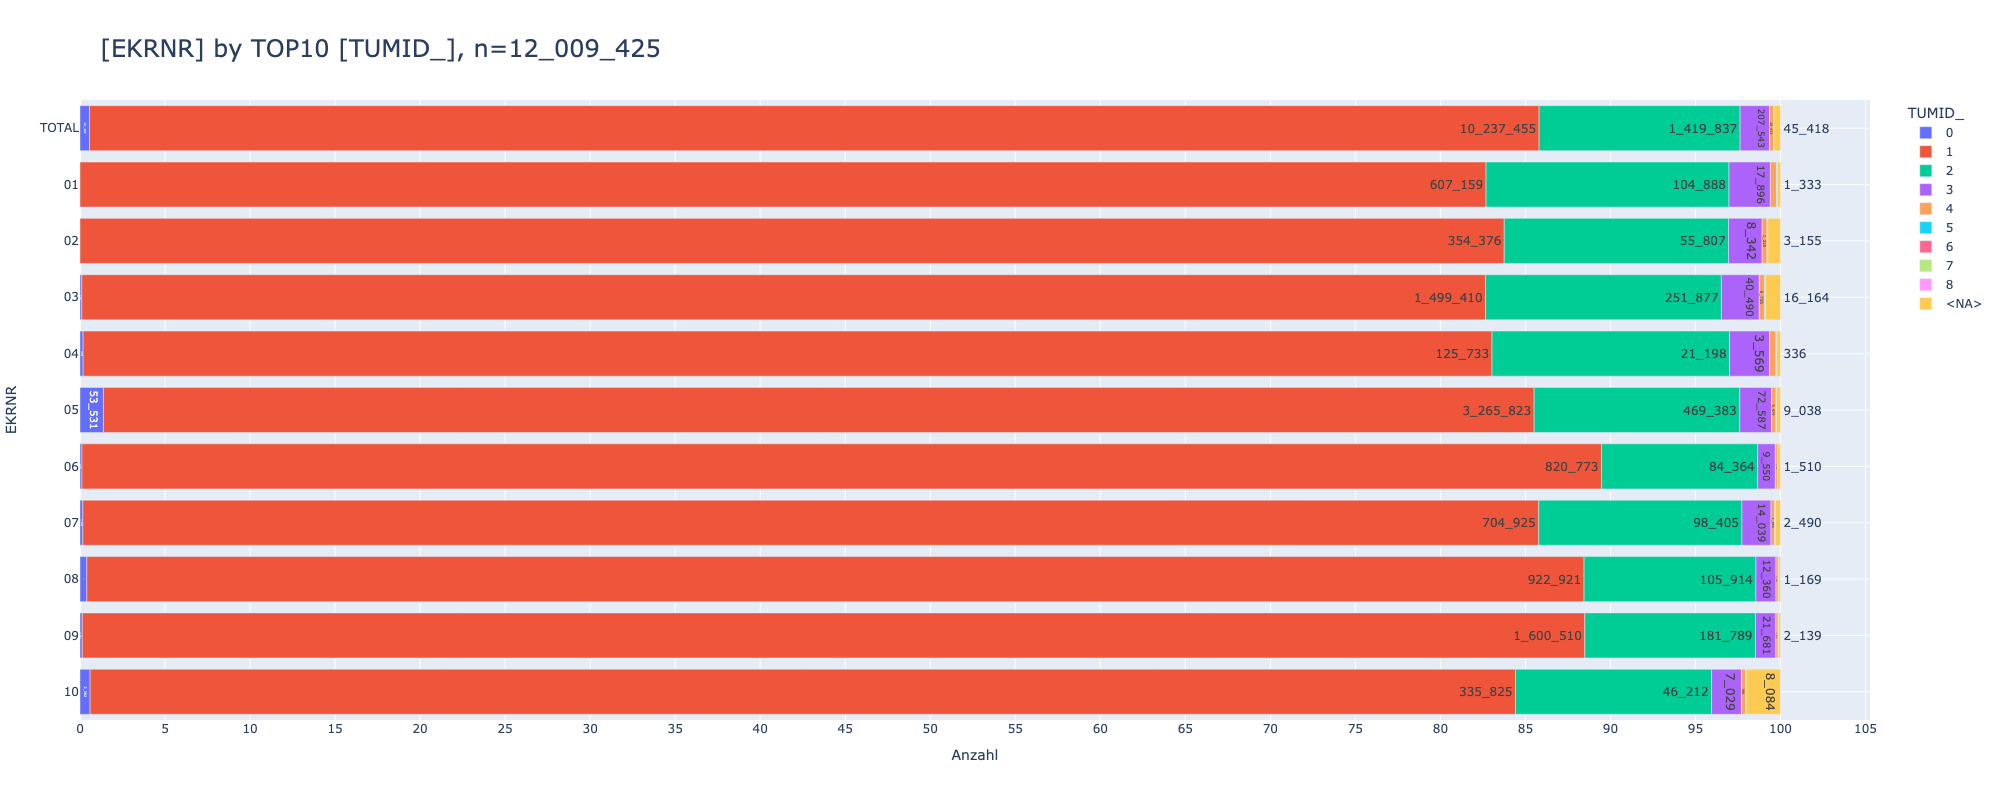

In [8]:
examine_tumid(df_epi_old)

### <a id='toc1_4_3_'></a>[Beispiel aus _neuen epi Daten_: Person mit max. Anzahl Tumormeldungen](#toc0_)
- derzeit: max 54 (mit TUMID gezählte) Fälle zu einer Person, davon hier 10 gezeigt

In [17]:
_cols = ["EKRNR", "TUMID", "DALTIMP", "ICDGM10DREI", "ICDO3", "DSICH", "DIG", "HISC", "DCO", "DJ", "LOKGRP", "HISCGRP"]
_id=df_epi_new[df_epi_new["TUMID"] == df_epi_new["TUMID"].max()]["GLOBALPATID"].tolist()[0]
df_epi_new[df_epi_new["GLOBALPATID"]==_id].sort_values("TUMID")[:10][_cols]
# ? kombos: 100 pat mit tumin > 2 UND tumid leer, nur KKR 11-16

,EKRNR,TUMID,DALTIMP,ICDGM10DREI,ICDO3,DSICH,DIG,HISC,DCO,DJ,LOKGRP,HISCGRP
1648505,14,1,68.0,C44,C4453,7,3,8091,2,2010.0,C44,2
1801754,14,2,68.0,C44,C4431,7,3,8092,2,2010.0,C44,2
2023551,14,3,68.0,C44,C4432,7,3,8090,2,2010.0,C44,2
2085456,14,4,68.0,C44,C4452,7,3,8091,2,2010.0,C44,2
260086,14,5,68.0,C44,C4461,7,3,8091,2,2010.0,C44,2
1876139,14,6,69.0,C44,C4451,7,3,8091,2,2011.0,C44,2
1358970,14,7,69.0,C44,C4453,7,3,8091,2,2011.0,C44,2
2215455,14,8,69.0,C44,C4451,7,3,8090,2,2011.0,C44,2
534684,14,9,69.0,C44,C4453,7,3,8091,2,2011.0,C44,2
1964870,14,10,70.0,C44,C4461,7,3,8091,2,2012.0,C44,2


## <a id='toc1_5_'></a>[Datenstand 🕥](#toc0_)

In [10]:
print(f"new data to sql: {df_epi_new['when_1_to_view'].max()}")
print(f"old data to sql: {df_epi_old['CREATED'].max()}")
print(f"notebook as of : {dt.datetime.now().isoformat(sep=' ', timespec='seconds')}")

new data to sql: 2024-06-07 13:38:35
old data to sql: 2024-06-18 14:44:34
notebook as of : 2024-06-23 21:11:09
